# **4. FastText**

El modelo **FastText**, desarrollado por Facebook AI Research, es una extensión del enfoque Word2Vec que descompone las palabras en subpalabras o n-gramas de caracteres. Esto permite capturar información morfológica, volviéndose especialmente útil en textos con vocabulario diverso, errores ortográficos o palabras poco frecuentes.


El modelo recibe como entrada los textos ya normalizados en formato __label__Clase texto, donde cada línea corresponde a un ejemplo de entrenamiento. FastText entrena mediante descenso de gradiente estocástico, ajustando parámetros como la tasa de aprendizaje (lr), el número de épocas (epoch), la dimensión del embedding (dim) y el tamaño del contexto (wordNgrams).

In [1]:
# [Librerias]

import os, time, joblib, re
import numpy as np
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

In [6]:
# MODULO DE MANEJO DE DATOS
# ---------------------------------
# --- Limpieza de texto ---
def limpiar_texto(txt):
    txt = str(txt).lower().strip()
    txt = re.sub(r"[^a-záéíóúñü0-9 ]+", " ", txt)
    return re.sub(r"\s+", " ", txt)

# --- Limpieza de etiquetas ---
def limpiar_label(lbl):
    lbl = str(lbl).strip().lower()
    lbl = re.sub(r"[^a-z0-9]+", "_", lbl)  # evita espacios o tildes
    return lbl

#  [Carga de datos]
df = pd.read_json('../Data/clean_words.json', lines=True)
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

df["Category"] = df["Category"].apply(limpiar_label)
df["fasttext_text"] = df["clean_text"].apply(limpiar_texto)

# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])
num_classes = len(le.classes_)
print(f"Número de clases: {num_classes}")

train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")


Registros totales: 2483
Número de clases: 5
Train: 1738 | Val: 372 | Test: 373


## 🔹Modelo

In [7]:
# MODULO DATASET

# Archivos FastText
def to_fasttext_format(df, text_col="fasttext_text", label_col="Category"):
    return [f"__label__{df.iloc[i][label_col]} {df.iloc[i][text_col]}" for i in range(len(df))]

def exportar_fasttext_archivos(train, val, test, carpeta="data_fasttext"):
    os.makedirs(carpeta, exist_ok=True)
    with open(os.path.join(carpeta, "train.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(train)))
    with open(os.path.join(carpeta, "val.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(val)))
    with open(os.path.join(carpeta, "test.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(test)))

exportar_fasttext_archivos(train, val, test)

In [10]:
# MODULO ENTRENAMIENTO
# ------------------------------------------------------
params = {
    "lr": 0.5,
    "epoch": 20,
    "wordNgrams": 2,
    "dim": 100,
    "loss": "ova", # Perdida (one-vs-all) para clases desbalanceadas
    "minCount": 2,
    "seed": SEED
}

base_dir = "results/FastText"
os.makedirs(base_dir, exist_ok=True)
model_path = os.path.join(base_dir, "fasttext_model.bin")

start = time.time()
model = fasttext.train_supervised(
    input="data_fasttext/train.txt",
    **params,
    verbose=2
)
print("\n🔹Tiempo de entrenamiento: %.2f minutos" % ((time.time() - start) / 60))
model.save_model(model_path)


🔹Tiempo de entrenamiento: 0.43 minutos


## 🔹Evaluación de rendimiento

EVALUACION DEL MODELO

=== HIPERPARAMETROS DEL MODELO ===
lr: 0.5
epoch: 20
wordNgrams: 2
dim: 100
loss: ova
minCount: 2
seed: 42

=== MÉTRICAS EN VALIDACIÓN ===
Accuracy: 0.7823 | F1-macro: 0.7809

=== MÉTRICAS EN TEST ===
Accuracy: 0.7078 | F1-macro: 0.7008

=== CLASSIFICATION REPORT (TEST) ===
                                    precision    recall  f1-score   support

          creatividad_y_producci_n       0.72      0.62      0.67        63
               negocios_y_finanzas       0.78      0.70      0.74        88
            otros_y_especializados       0.64      0.58      0.61        71
servicios_profesionales_y_p_blicos       0.73      0.82      0.77        84
              tecnolog_a_y_ciencia       0.65      0.79      0.72        67

                          accuracy                           0.71       373
                         macro avg       0.71      0.70      0.70       373
                      weighted avg       0.71      0.71      0.71       373



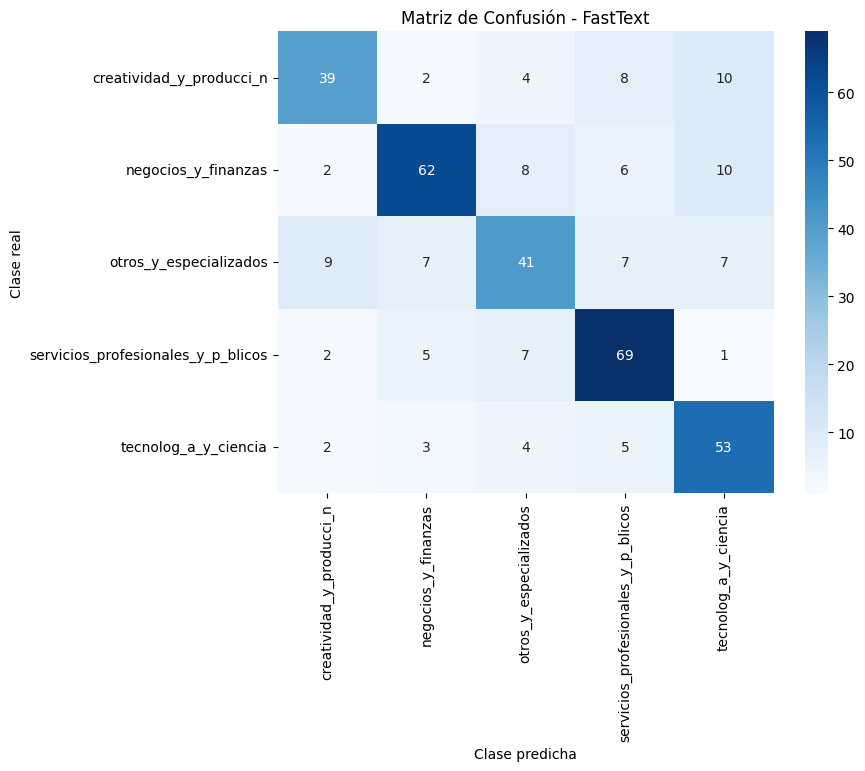

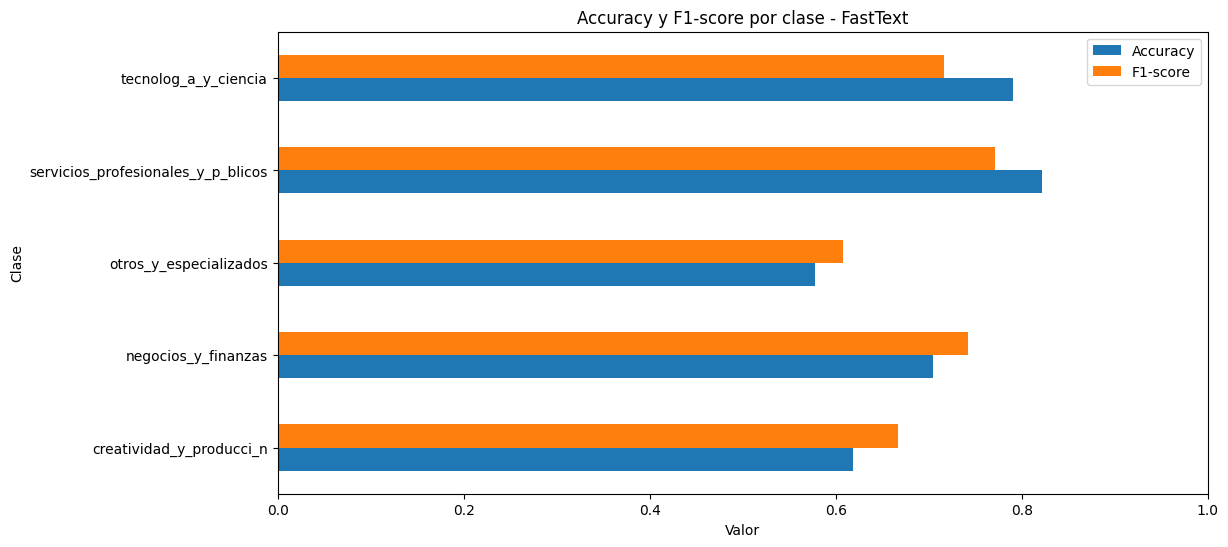

In [11]:
# ------------------------------------------------------
# EVALUACION DEL MODELO
# ------------------------------------------------------
print("EVALUACION DEL MODELO")

# ---- Hiperparámetros ----
print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Validación ----
def get_predictions_fasttext(model, df):
    preds, labels = [], []
    for text, label in zip(df["fasttext_text"], df["Category"]):
        try:
            pred_label, _ = model.predict(str(text))
            pred = pred_label[0].replace("__label__", "")
        except Exception:
            pred = "UNKNOWN"
        preds.append(pred)
        labels.append(label)
    return np.array(labels), np.array(preds)

# --- Validación ---
val_labels, val_preds = get_predictions_fasttext(model, val)
val_labels_enc = le.transform(val_labels)
val_preds_enc = le.transform([p if p in le.classes_ else np.random.choice(le.classes_) for p in val_preds])
val_acc = accuracy_score(val_labels_enc, val_preds_enc)
val_f1 = f1_score(val_labels_enc, val_preds_enc, average='macro')
print("\n=== MÉTRICAS EN VALIDACIÓN ===")
print(f"Accuracy: {val_acc:.4f} | F1-macro: {val_f1:.4f}")

# --- Test ---
test_labels, test_preds = get_predictions_fasttext(model, test)
test_labels_enc = le.transform(test_labels)
test_preds_enc = le.transform([p if p in le.classes_ else np.random.choice(le.classes_) for p in test_preds])
test_acc = accuracy_score(test_labels_enc, test_preds_enc)
test_f1 = f1_score(test_labels_enc, test_preds_enc, average='macro')
print("\n=== MÉTRICAS EN TEST ===")
print(f"Accuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
target_names = le.classes_
report = classification_report(test_labels_enc, test_preds_enc, target_names=target_names, zero_division=0, output_dict=True)
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(test_labels_enc, test_preds_enc, target_names=target_names, zero_division=0))

# ---- Matriz de confusión ----
cm = confusion_matrix(test_labels_enc, test_preds_enc)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión - FastText")
plt.show()

# ---- Gráfico de métricas por clase (Acc y F1) ----
per_class_f1 = [report[label]['f1-score'] for label in target_names]
per_class_acc = [np.mean((test_preds_enc[test_labels_enc==i] == i)) for i, _ in enumerate(target_names)]

metrics_plot_df = pd.DataFrame({
    "Clase": target_names,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})

metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='barh', figsize=(12,6))  
plt.title("Accuracy y F1-score por clase - FastText")
plt.xlabel("Valor") 
plt.xlim(0,1)        
plt.yticks(rotation=0)
plt.show()


El modelo FastText con pérdida One-vs-All (OVA), presenta un buen desempeño general, alcanzando un F1-macro de 0.78 en validación y 0.70 en prueba, lo cual indica una ligera pérdida de rendimiento al enfrentarse a datos nuevos. 

En el análisis por categorías, se observa que las clases _Servicios profesionales y públicos_ es la que obtiene mejores resultados globales, con pocas equivocaciones al clasificarlo, por eso tiene el recall más alto. Sin embargo, el grupo _Otros y especializados_ tuvo el peor desempeño con un recall de apenas 52%. Esto indica que si bien el modelo tiene un rendimiento moderado, existe un desbalance hacia una clase mayoritaria. En conjunto, los resultados evidencian un modelo es consistente y equilibrado, de rendimiento regular, que prioriza la clasificación de unas clases frente a otras.